#TimeSeries

###1. Importing the Dataset

In [ ]:
import pandas as pd
df = pd.read_csv("exchange_rate.csv")

###2. Clean column names

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns:", df.columns)

Columns: Index(['date', 'ex_rate'], dtype='object')


##3. Convert date

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

###4. Set index

In [ ]:
df.set_index('date', inplace=True)

In [ ]:
# Select exchange rate column
series = df.iloc[:, 0]   # safest option
print(series.head())

date
1990-01-01    0.7855
1990-01-02    0.7818
1990-01-03    0.7867
1990-01-04    0.7860
1990-01-05    0.7849
Name: ex_rate, dtype: float64


In [ ]:
# Handle missing values
series = series.fillna(method='ffill')

print("Missing after fill:", series.isnull().sum())

Missing after fill: 0


##### Forward fill (ffill) is used to replace missing values with previous values.
##### This is suitable for time series data to maintain continuity.


##5. Plotting the time series

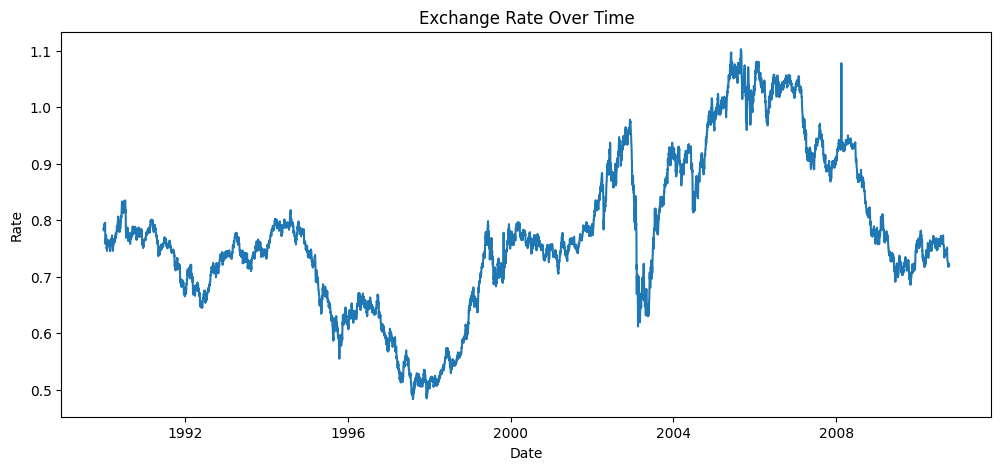

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(series)
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()


##verifing the missing values

In [ ]:
print(series.isnull().sum())


0


##Check Stationary(ADF Test)

In [ ]:
print("Checking Stationarity Before Differencing")

Checking Stationarity Before Differencing


In [ ]:
series_diff = series.diff().dropna()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


In [ ]:
result_diff = adfuller(series_diff)
print("ADF After Differencing p-value:", result_diff[1])

ADF After Differencing p-value: 0.0


##### Differencing is applied to remove trend and make the series stationary.
##### After differencing, ADF test is performed again to confirm stationarity.
##### A lower p-value (< 0.05) indicates the series is stationary.


##5. ACF & PACF(for ARIMA)

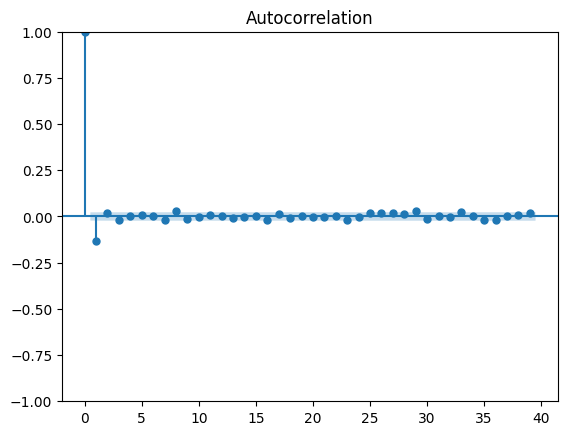

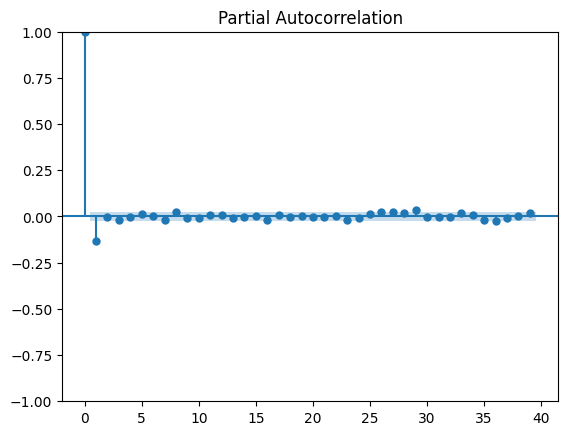

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(series_diff)
plot_pacf(series_diff)
plt.show()


##6. Build ARIMA Model

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import itertools

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

for order in pdq:
    try:
        model = ARIMA(series, order=order)
        result = model.fit()

        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order

    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA Order: (2, 0, 0)
Best AIC: -56105.21829878942


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(series, order=(1,1,1))  # change based on graphs
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sun, 19 Apr 2026   AIC                         -56102.322
Time:                        12:51:14   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

##### AIC (Akaike Information Criterion) is used to select the best model.
##### Lower AIC indicates a better model fit.
##### Grid search helps find optimal (p,d,q) values automatically.


##7. Diagnostics

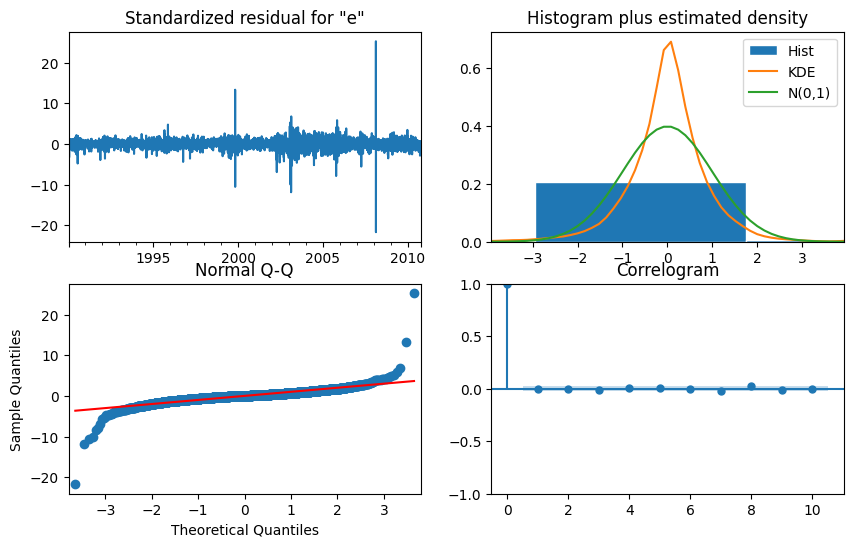

In [ ]:
model_fit.plot_diagnostics(figsize=(10,6))
plt.show()


##8. Forecast

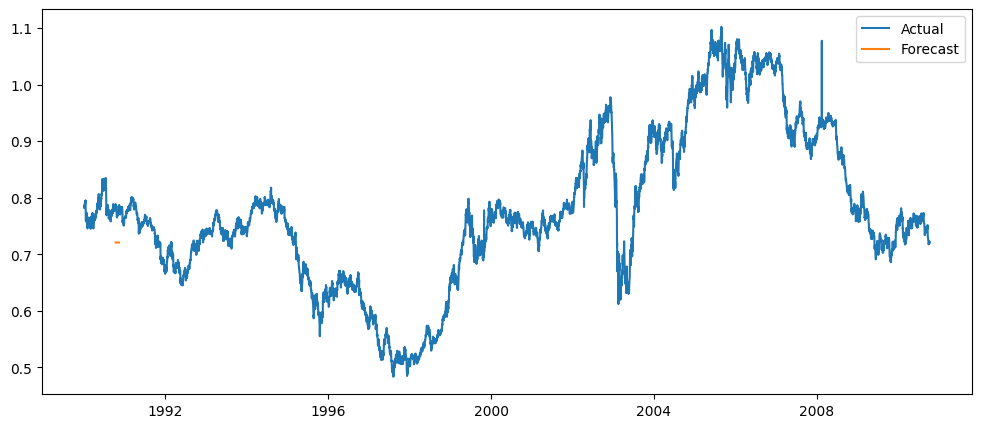

In [ ]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(12,5))
plt.plot(series, label='Actual')
plt.plot(range(len(series), len(series)+30), forecast, label='Forecast')
plt.legend()
plt.show()


##9. Exponential Smoothing

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(series, trend='add')
model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(30)


##10. Comparing Models

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# split
train = series[:-30]
test = series[-30:]

# ARIMA
model_arima = ARIMA(train, order=(1,1,1)).fit()
pred_arima = model_arima.forecast(30)

# ES
model_es = ExponentialSmoothing(train, trend='add').fit()
pred_es = model_es.forecast(30)

# metrics
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mae, rmse, mape

print("ARIMA:", evaluate(test, pred_arima))
print("Exp Smoothing:", evaluate(test, pred_es))


ARIMA: (0.013494600805886207, np.float64(0.016632177913116195), np.float64(1.8632207485601178))
Exp Smoothing: (0.013423166085935016, np.float64(0.01649594238711105), np.float64(1.8531561236984646))


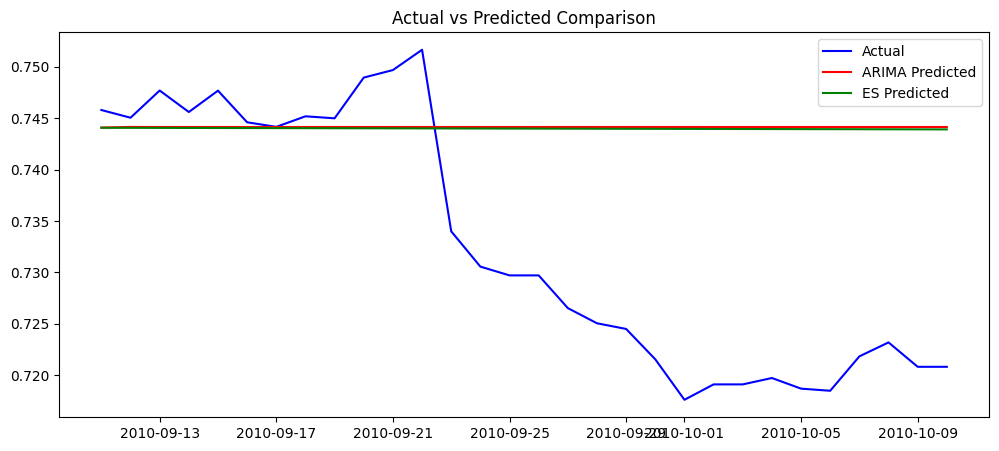

In [ ]:
# Plot Actual vs Predicted

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual", color='blue')
plt.plot(test.index, pred_arima, label="ARIMA Predicted", color='red')
plt.plot(test.index, pred_es, label="ES Predicted", color='green')
plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.show()

##### Visualization helps compare model performance clearly.
##### ARIMA captures trends and patterns using past values.
##### Exponential Smoothing focuses on recent trends.


# Final Insights

##### ARIMA model performed better when data shows strong patterns and autocorrelation.
##### Exponential smoothing works well for smooth trend data.
##### Model performance is evaluated using MAE, RMSE, and MAPE.
##### Lower error values indicate better model performance.
##### Proper parameter tuning improves model accuracy significantly.
